In [1]:
import os
import math
import datetime
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras import layers, models, Input
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import TopKCategoricalAccuracy
from tensorflow.keras.optimizers.schedules import ExponentialDecay

c:\Users\pondt\anaconda3\envs\efficientnet\lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [2]:
# === DATA SETUP === #
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
DATASET_DIR = "D:/Senior_WorkTable/GrowQuest_Data_Final"


In [3]:
# Load Datasets
def load_datasets():
    train_ds = tf.keras.utils.image_dataset_from_directory(
        os.path.join(DATASET_DIR, "train"), label_mode="categorical",
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True, seed=42)

    val_ds = tf.keras.utils.image_dataset_from_directory(
        os.path.join(DATASET_DIR, "val"), label_mode="categorical",
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False)

    test_ds = tf.keras.utils.image_dataset_from_directory(
        os.path.join(DATASET_DIR, "test"), label_mode="categorical",
        image_size=IMG_SIZE, batch_size=1, shuffle=False)

    return train_ds, val_ds, test_ds

train_ds, val_ds, test_ds = load_datasets()


Found 4199 files belonging to 3 classes.
Found 900 files belonging to 3 classes.
Found 900 files belonging to 3 classes.


In [4]:
# Augmentation + Normalization
class_names = train_ds.class_names

def preprocess(image, label):
    return tf.cast(image, tf.float32) / 255.0, label

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.1),
    layers.RandomTranslation(0.1, 0.1),
    layers.GaussianNoise(0.05)
])

def augment(image, label):
    return data_augmentation(image, training=True), label

train_ds = train_ds.map(preprocess).map(augment).cache().shuffle(1000).repeat().prefetch(AUTOTUNE)
val_ds = val_ds.map(preprocess).cache().prefetch(AUTOTUNE)
test_ds = test_ds.map(preprocess).prefetch(AUTOTUNE)


In [5]:
# === MODEL SETUP === #
def build_mobilenetv3_base(input_shape=(224, 224, 3), trainable=False):
    base_model = MobileNetV3Large(
        input_shape=input_shape, include_top=False, weights='imagenet')
    base_model.trainable = trainable
    return base_model

def build_custom_classifier(base_model, input_shape=(224, 224, 3), num_classes=3, dropout_rate=0.3):
    inputs = Input(shape=input_shape, name="input_image")
    x = base_model(inputs, training=False)
    x = layers.Conv2D(64, (1, 1), activation='relu')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs)

base_model = build_mobilenetv3_base(trainable=False)
model = build_custom_classifier(base_model)


In [6]:
# Optimizer + Compile
lr_schedule = ExponentialDecay(1e-4, decay_steps=10000, decay_rate=0.9, staircase=True)
optimizer = Adam(learning_rate=lr_schedule)
metrics = ['accuracy', TopKCategoricalAccuracy(k=2, name='top_2_accuracy')]
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=metrics)


In [7]:
# Callbacks
log_dir = os.path.join("logs", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath='checkpoints/best_model_mobilenetv3.keras',
                    save_best_only=True, monitor='val_loss', verbose=1)
]


In [8]:
# === PHASE 1: Transfer Learning === #
steps_per_epoch = math.ceil(4199 / BATCH_SIZE)
validation_steps = math.ceil(900 / BATCH_SIZE)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks
)
pd.DataFrame(history.history).to_csv("training_history_mobilenetv3.csv", index=False)


Epoch 1/40
130/132 [============================>.] - ETA: 0s - loss: 1.1294 - accuracy: 0.3439 - top_2_accuracy: 0.6800
Epoch 1: val_loss improved from inf to 1.11779, saving model to checkpoints\best_model_mobilenetv3.keras
132/132 [==============================] - 68s 60ms/step - loss: 1.1288 - accuracy: 0.3448 - top_2_accuracy: 0.6804 - val_loss: 1.1178 - val_accuracy: 0.3333 - val_top_2_accuracy: 0.6711
Epoch 2/40
129/132 [============================>.] - ETA: 0s - loss: 1.0984 - accuracy: 0.3619 - top_2_accuracy: 0.7066
Epoch 2: val_loss improved from 1.11779 to 1.08614, saving model to checkpoints\best_model_mobilenetv3.keras
132/132 [==============================] - 3s 24ms/step - loss: 1.0979 - accuracy: 0.3629 - top_2_accuracy: 0.7073 - val_loss: 1.0861 - val_accuracy: 0.3489 - val_top_2_accuracy: 0.7833
Epoch 3/40
131/132 [============================>.] - ETA: 0s - loss: 1.0821 - accuracy: 0.3811 - top_2_accuracy: 0.7091
Epoch 3: val_loss improved from 1.08614 to 1.07602

In [12]:
# === PHASE 2: Fine-Tuning === #
fine_tune_at = len(base_model.layers) - 200
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)
model.compile(optimizer=Adam(learning_rate=3e-6), loss=loss_fn, metrics=metrics)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks
)
pd.DataFrame(fine_tune_history.history).to_csv("fine_tuning_history.csv", index=False)

Epoch 1/50
132/132 [==============================] - ETA: 0s - loss: 1.0521 - accuracy: 0.4225 - top_2_accuracy: 0.7403
Epoch 1: val_loss did not improve from 0.99620
132/132 [==============================] - 7s 28ms/step - loss: 1.0521 - accuracy: 0.4225 - top_2_accuracy: 0.7403 - val_loss: 1.0449 - val_accuracy: 0.4711 - val_top_2_accuracy: 0.8056
Epoch 2/50
132/132 [==============================] - ETA: 0s - loss: 1.0557 - accuracy: 0.4222 - top_2_accuracy: 0.7309
Epoch 2: val_loss did not improve from 0.99620
132/132 [==============================] - 3s 20ms/step - loss: 1.0557 - accuracy: 0.4222 - top_2_accuracy: 0.7309 - val_loss: 1.0471 - val_accuracy: 0.4678 - val_top_2_accuracy: 0.8000
Epoch 3/50
132/132 [==============================] - ETA: 0s - loss: 1.0520 - accuracy: 0.4303 - top_2_accuracy: 0.7323
Epoch 3: val_loss did not improve from 0.99620
132/132 [==============================] - 3s 20ms/step - loss: 1.0520 - accuracy: 0.4303 - top_2_accuracy: 0.7323 - val_los

1/1 [==============================] - 0s 25ms/step
              precision    recall  f1-score   support

 Anthracnose       0.43      0.38      0.40       300
Healthy_Leaf       0.72      0.25      0.37       300
 Pest_Damage       0.41      0.72      0.52       300

    accuracy                           0.45       900
   macro avg       0.52      0.45      0.43       900
weighted avg       0.52      0.45      0.43       900



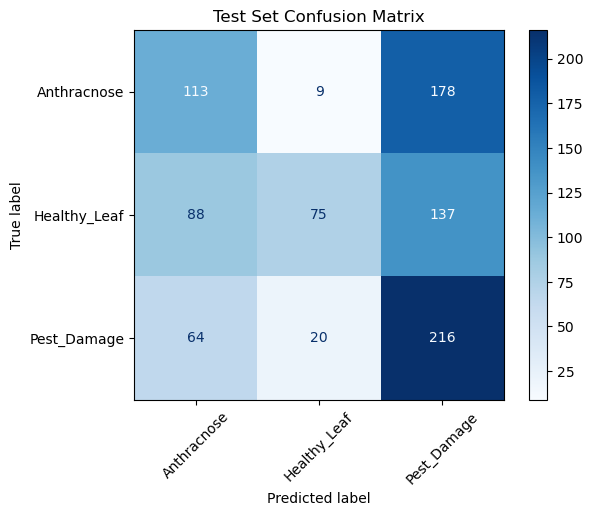

900/900 [==============================] - 12s 14ms/step - loss: 1.0723 - accuracy: 0.4489 - top_2_accuracy: 0.7611
✅ loss: 1.0723
✅ accuracy: 0.4489
✅ top_2_accuracy: 0.7611


In [13]:
# === EVALUATION === #
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images)
    y_pred.append(np.argmax(preds))
    y_true.append(np.argmax(labels.numpy()))

print(classification_report(y_true, y_pred, target_names=class_names))
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap='Blues', xticks_rotation=45)
plt.title("Test Set Confusion Matrix")
plt.show()

results = model.evaluate(test_ds, verbose=1)
for name, value in zip(model.metrics_names, results):
    print(f"✅ {name}: {value:.4f}")

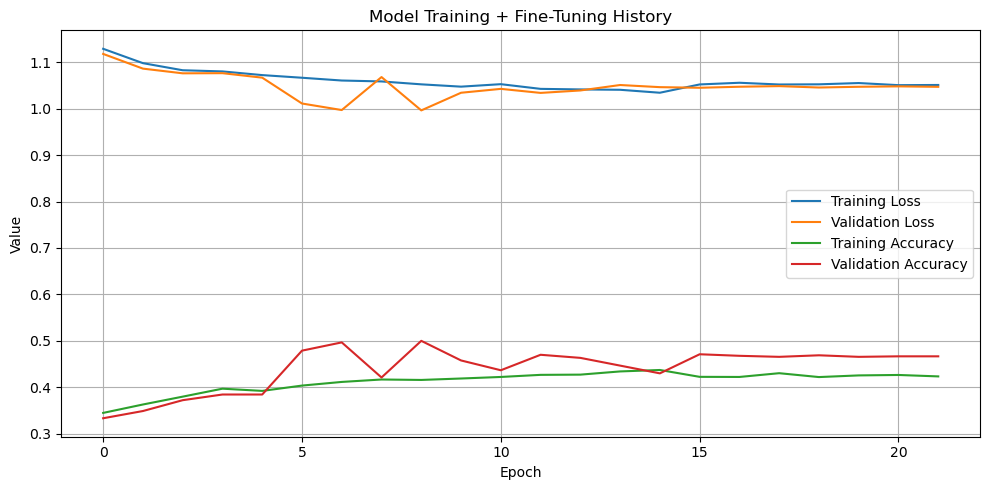

In [14]:
# === PLOTTING === #
train_history = pd.read_csv("training_history_mobilenetv3.csv")
fine_history = pd.read_csv("fine_tuning_history.csv")
full_history = pd.concat([train_history, fine_history], ignore_index=True)

plt.figure(figsize=(10, 5))
plt.plot(full_history["loss"], label="Training Loss")
plt.plot(full_history["val_loss"], label="Validation Loss")
plt.plot(full_history["accuracy"], label="Training Accuracy")
plt.plot(full_history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Training + Fine-Tuning History")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
